# DINOv3 ViT — Feature Extraction & Invariance Analysis (raw)

Same as `invariance_DinoV3_vit.ipynb` but features are **not** pooled.
All patch tokens are flattened → `(B, 64×768)` per layer.
Register tokens are excluded; tokens are z-scored across the feature dimension before flattening.

In [3]:
import os, sys
import torch
import numpy as np
from PIL import Image
from scipy.io import loadmat
from transformers import AutoImageProcessor, DINOv3ViTModel
import matplotlib.pyplot as plt

sys.path.append('../utils')
import util

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Load DINOv3 ViT

In [4]:
repo_id = 'facebook/dinov3-vitb16-pretrain-lvd1689m'
token = os.getenv("HF_TOKEN")
processor = AutoImageProcessor.from_pretrained(repo_id, token=token)
model = DINOv3ViTModel.from_pretrained(repo_id, token=token).to(device).eval()

n_layers    = model.config.num_hidden_layers
n_reg       = model.config.num_register_tokens
patch_start = 1 + n_reg
layer_names = [f'B{i}' for i in range(1, n_layers + 1)]

print(f'num_hidden_layers  : {n_layers}')
print(f'hidden_size        : {model.config.hidden_size}')
print(f'num_register_tokens: {n_reg}')
print(f'patch_start        : {patch_start}')

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

num_hidden_layers  : 12
hidden_size        : 768
num_register_tokens: 4
patch_start        : 5


## Load & preprocess images

In [5]:
mat = loadmat('../data/miguel_passive8x4.mat')
images_gray = np.transpose(mat['img'].astype(np.float32), (2, 0, 1))  # (32, 150, 600)
nimg = len(images_gray)
print(f'images_gray: {images_gray.shape}  range: {images_gray.min():.0f}–{images_gray.max():.0f}')

images_rgb = [
    Image.fromarray(images_gray[i].astype(np.uint8)).resize((256, 64), Image.BICUBIC).convert('RGB')
    for i in range(nimg)
]
print(f'prepared {nimg} images, size: {images_rgb[0].size}')

images_gray: (32, 150, 600)  range: 0–255
prepared 32 images, size: (256, 64)


## Extract hidden states

In [6]:
inputs = processor(images=images_rgb, return_tensors='pt',
                   do_resize=False, do_center_crop=False)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True, interpolate_pos_encoding=True)

hidden = np.stack([h.cpu().numpy() for h in outputs.hidden_states], axis=0)  # (13, 32, 69, 768)
print('hidden states shape:', hidden.shape)

hidden = hidden[1:]   # (12, 32, 69, 768) — drop embedding
print('after dropping embedding:', hidden.shape)

hidden states shape: (13, 32, 69, 768)
after dropping embedding: (12, 32, 69, 768)


## Z-score across feature dim, then flatten patch tokens

In [7]:
mean = hidden.mean(axis=-1, keepdims=True)
std  = hidden.std(axis=-1,  keepdims=True)
hidden_z = (hidden - mean) / (std + 1e-6)   # (12, 32, 69, 768)

# Patch tokens: skip CLS + register tokens, flatten patches × dims
patch_tokens = hidden_z[:, :, patch_start:, :]        # (12, 32, 64, 768)
flat = patch_tokens.reshape(n_layers, nimg, -1)        # (12, 32, 49152)

print('patch_tokens shape:', patch_tokens.shape)
print('flat         shape:', flat.shape)

features = np.empty(n_layers, dtype=object)
for i in range(n_layers):
    features[i] = flat[i]   # (32, 49152)
    print(f'  {layer_names[i]}: {features[i].shape}')

patch_tokens shape: (12, 32, 64, 768)
flat         shape: (12, 32, 49152)
  B1: (32, 49152)
  B2: (32, 49152)
  B3: (32, 49152)
  B4: (32, 49152)
  B5: (32, 49152)
  B6: (32, 49152)
  B7: (32, 49152)
  B8: (32, 49152)
  B9: (32, 49152)
  B10: (32, 49152)
  B11: (32, 49152)
  B12: (32, 49152)


## Compute invariance

In [8]:
rep_mtx  = util.compute_model_rep_mtx(features)
invar_df = util.compute_pair_inv_model(rep_mtx)
print('Invariance computed.')

Invariance computed.


## Summarise and save

In [9]:
grp = invar_df.groupby('layer')['pair_invariance']
inv_summary = {
    'layer_names': layer_names,
    'mean': grp.mean().values,
    'std':  grp.std().values,
}

os.makedirs('outputs', exist_ok=True)
np.save('outputs/dinov3_vit_inv_raw.npy', inv_summary, allow_pickle=True)
np.save('outputs/dinov3_vit_flat_features.npy', features, allow_pickle=True)
print('Saved.')

print('\nPer-block mean invariance:')
for name, m, s in zip(layer_names, inv_summary['mean'], inv_summary['std']):
    print(f'  {name}: {m:.4f} ± {s:.4f}')

Saved.

Per-block mean invariance:
  B1: 0.0034 ± 0.0034
  B2: 0.0220 ± 0.0220
  B3: 0.0439 ± 0.0419
  B4: 0.0953 ± 0.0674
  B5: 0.1374 ± 0.0627
  B6: 0.1293 ± 0.0440
  B7: 0.1225 ± 0.0407
  B8: 0.1183 ± 0.0435
  B9: 0.1700 ± 0.0556
  B10: 0.1676 ± 0.0615
  B11: 0.1919 ± 0.0859
  B12: 0.1871 ± 0.0530


## Plot

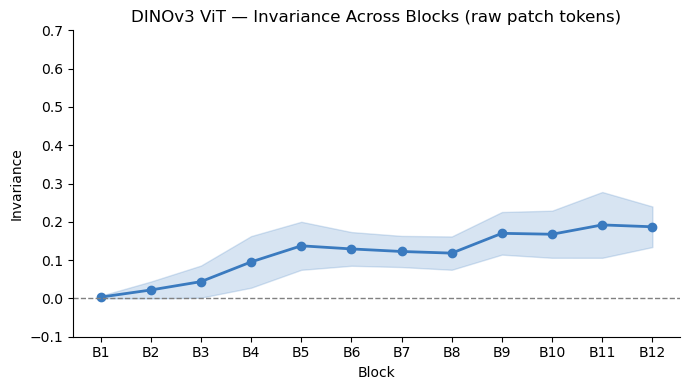

In [10]:
mean = inv_summary['mean']
std  = inv_summary['std']
x    = np.arange(n_layers)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean, 'o-', color='#3a7abf', lw=2, ms=6)
ax.fill_between(x, mean - std, mean + std, alpha=0.2, color='#3a7abf')
ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_ylim(-0.1, 0.7)
ax.set_xticks(x)
ax.set_xticklabels(layer_names, fontsize=10)
ax.set_xlabel('Block')
ax.set_ylabel('Invariance')
ax.set_title('DINOv3 ViT — Invariance Across Blocks (raw patch tokens)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/dinov3_vit_invariance_raw.png', dpi=300, bbox_inches='tight')
plt.show()